<a href="https://colab.research.google.com/github/ShiYu0318/ShiYu-AI-Courses-Archive/blob/main/Gradient_Descent_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 梯度下降演算法（Gradient Descent）
本教學以一個簡單的線性迴歸問題：**以讀書時長預測考試分數** 從零實作梯度下降法。


| 區塊 | 內容 | 重點 |
|------|------|------|
| 1-2 | 生成資料、互動式預測線 | 建立直覺：什麼是好的預測線 |
| 3-5 | Cost Function、暴力窮舉、3D 曲面 | 理解最佳化在找什麼 |
| 6-9 | 梯度計算、梯度下降實作、收斂曲線 | 核心演算法 |
| 10 | Learning Rate 比較 | 超參數對訓練的影響 |
| 11 | sklearn 驗證 | 確認手刻結果的正確性 |

## 1. 生成模擬資料

使用 sklearn 的 make_regression 生成帶有雜訊的線性資料，並透過 Min-Max Normalization 縮放到合理範圍：
- **x**（讀書時數）：1 ~ 10
- **y**（考試分數）：20 ~ 95

In [ ]:
from sklearn.datasets import make_regression
import numpy as np

# 生成單特徵線性迴歸資料
x, y = make_regression(n_samples=30, n_features=1, noise=10, bias=20, random_state=42)

# 從二維壓成一維
x = x.flatten()

# Min-Max Normalization 縮放資料範圍
x = (x - x.min()) / (x.max() - x.min()) * 9 + 1   # 讀書時數 1~10
y = (y - y.min()) / (y.max() - y.min()) * 75 + 20  # 考試分數 20~95

## 2. 可視化資料與互動式調整預測線

將資料可視化並使用 ipywidgets 的 interact 拖動滑桿手動調整 w（斜率）和 b（截距），感受不同參數對預測線的影響

我們的模型是一條直線：
$$
\hat{y} = w \cdot x + b\
$$

In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interact

def plot_pred(w, b):

    # 初始化預測線權重
    y_pred = x * w + b

    # 畫資料點分布
    plt.scatter(x, y, color="blue", label="data")

    # 畫預測線
    plt.plot(x, y_pred, color="red", label="predict")

    # 軸標題
    plt.xlabel("Study Hours")
    plt.ylabel("Scores")

    # 範圍限制
    plt.xlim([0, 12])
    plt.ylim([0, 100])

    # 顯示圖例
    plt.legend()

    # 顯示圖表
    plt.show()

# 使用互動元件動態調整並顯示
interact(plot_pred, w=(-100, 100, 1), b=(-100, 100, 1));

## 3. 定義成本函數（Cost Function）

我們需要一個指標來衡量預測誤差，在此使用 **均方誤差（MSE）**：

$$
J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

- $\hat{y}_i = w \cdot x_i + b$（模型的預測值）
- 實際值越小，代表預測越準確

In [ ]:
def compute_cost(x, y, w, b):
    # MSE
    y_pred = w * x + b
    cost = ((y_pred - y) ** 2).mean()
    return cost

# 測試：計算在 w=0, b=0 時的 cost
print(f"在 w=0, b=0 時的 cost: {compute_cost(x, y, 0, 0):.2f}")

w=0, b=0 時的 cost: 3894.43


## 4. 暴力窮舉法（Brute Force）

先用最直觀的方法：
枚舉所有參數組合，找出誤差最小的解

嘗試 $ w \in [−100,100], b \in [−100,100] $ 的所有整數組合，對每組 $(w,b)$ 計算對應的 loss（誤差）
選出 loss 最小的參數

此方法僅用於視覺化損失平面，計算量為 $O(n^2)$，實務上不可行

In [ ]:
# 建立參數空間（w, b）
ws = np.arange(-100, 101)
bs = np.arange(-100, 101)

# 初始化 loss 紀錄表
costs = np.zeros((len(ws), len(bs)))

# 計算每組 (w, b) 的 loss
for i, w in enumerate(ws):
    for j, b in enumerate(bs):
        costs[i, j] = compute_cost(x, y, w, b)

# 找出 loss 最小的位置（最佳參數）
w_idx, b_idx = np.where(costs == np.min(costs))
print(f"Best parameters: w={ws[w_idx][0]}, b={bs[b_idx][0]}, min cost={costs[w_idx, b_idx][0]:.2f}")

Best parameters: w=8, b=16, min cost=8.50


## 5. 3D 損失曲面圖

把所有 (w, b, cost) 畫成三維曲面，紅點是最低點，
拖動滑桿可以旋轉視角

In [ ]:
from ipywidgets import interact

def plot_3d(elev=45, azim=20):

    # 圖片尺寸
    fig = plt.figure(figsize=(10, 8))

    ax = fig.add_subplot(111, projection="3d")

    # 初始化仰角、方位角
    ax.view_init(elev, azim)

    # 建立網格座標（對應 w, b）
    b_grid, w_grid = np.meshgrid(bs, ws)

    # 繪製 3D 曲面（cmp: 顏色, alpha: 透明度）
    ax.plot_surface(w_grid, b_grid, costs, cmap="Spectral_r", alpha=0.7)

    # 繪製網格
    ax.plot_wireframe(w_grid, b_grid, costs, color="black", alpha=0.1)

    # 標示最低點
    ax.scatter(ws[w_idx], bs[b_idx], costs[w_idx, b_idx], color="red", s=80, zorder=5)

    # 軸標題
    ax.set_xlabel("w")
    ax.set_ylabel("b")
    ax.set_zlabel("cost")
    ax.set_title("Cost Function Surface")
    plt.show()

interact(plot_3d, elev=(0, 90, 5), azim=(0, 360, 5));

## 6. 計算梯度（Gradient）

暴力法在參數量大時窮舉複雜度太高，於是用梯度下降的核心想法：**沿著斜坡最陡的方向往下走**

對 MSE 做偏微分：

$$
\frac{\partial J}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} 2 x_i \, (\hat{y}_i - y_i)
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2(\hat{y}_i - y_i)
$$

梯度告訴我們往哪個方向調整 w 和 b，cost 會下降最快

In [ ]:
def compute_gradient(x, y, w, b):
    y_pred = w * x + b
    w_gradient = (2 * x * (y_pred - y)).mean()
    b_gradient = (2 * (y_pred - y)).mean()
    return w_gradient, b_gradient

# 測試：在 w=0, b=0 的梯度方向
dw, db = compute_gradient(x, y, 0, 0)
print(f"w=0, b=0 gradient：dw={dw:.2f}, db={db:.2f}")

w=0, b=0 gradient：dw=-732.38, db=-119.23


## 7. 梯度下降主函式

每一步的更新規則：

$$
w \leftarrow w - \alpha \cdot \frac{\partial J}{\partial w}
$$

$$
b \leftarrow b - \alpha \cdot \frac{\partial J}{\partial b}
$$

其中 $\alpha$ 是 **learning rate**（學習率），控制每一步走多大


### Parameters
- w_init, b_init: 初始權重
- learning_rate: 學習率
- run_iter: 迭代次數
- p_iter: 每隔幾次印出一次進度

### Returns
- w, b: 最終權重
- history: dict，紀錄每一步的 w, b, cost

In [ ]:
def gradient_descent(x, y, w_init, b_init, learning_rate, run_iter, p_iter=100):

    # 初始化
    w, b = w_init, b_init

    # 紀錄每一步
    history = {"w": [w], "b": [b], "cost": [compute_cost(x, y, w, b)]}

    # 不斷更新
    for i in range(run_iter):

        # 計算梯度
        dw, db = compute_gradient(x, y, w, b)

        # 更新參數
        w -= learning_rate * dw
        b -= learning_rate * db

        # 計算成本函數
        cost = compute_cost(x, y, w, b)

        # 將新結果放進紀錄中
        history["w"].append(w)
        history["b"].append(b)
        history["cost"].append(cost)

        # 每隔 p_iter 次印出一次
        if i % p_iter == 0:
            print(f"Iter {i:5d} | cost: {cost:.4f} | w: {w:.4f} | b: {b:.4f}")

    return w, b, history

## 8. 執行梯度下降

In [ ]:
# 參數皆可自行調整
w_final, b_final, hist = gradient_descent(
    x, y,
    w_init=-100,
    b_init=-100,
    learning_rate=0.001,
    run_iter=10000,
    p_iter = 100,
)

print(f"Final: w={w_final:.4f}, b={b_final:.4f}")

Iter     0 | cost: 480051.5249 | w: -91.2077 | b: -98.5917
Iter   100 | cost: 1326.1267 | w: 22.6648 | b: -77.8800
Iter   200 | cost: 1251.3957 | w: 22.3108 | b: -75.1715
Iter   300 | cost: 1181.0593 | w: 21.8997 | b: -72.5514
Iter   400 | cost: 1114.7033 | w: 21.5005 | b: -70.0065
Iter   500 | cost: 1052.1023 | w: 21.1126 | b: -67.5346
Iter   600 | cost: 993.0440 | w: 20.7359 | b: -65.1337
Iter   700 | cost: 937.3279 | w: 20.3701 | b: -62.8017
Iter   800 | cost: 884.7647 | w: 20.0147 | b: -60.5366
Iter   900 | cost: 835.1762 | w: 19.6695 | b: -58.3366
Iter  1000 | cost: 788.3938 | w: 19.3343 | b: -56.1998
Iter  1100 | cost: 744.2590 | w: 19.0086 | b: -54.1242
Iter  1200 | cost: 702.6217 | w: 18.6923 | b: -52.1083
Iter  1300 | cost: 663.3407 | w: 18.3851 | b: -50.1502
Iter  1400 | cost: 626.2826 | w: 18.0867 | b: -48.2484
Iter  1500 | cost: 591.3217 | w: 17.7969 | b: -46.4011
Iter  1600 | cost: 558.3392 | w: 17.5154 | b: -44.6069
Iter  1700 | cost: 527.2232 | w: 17.2420 | b: -42.8642
I

## 9. 收斂曲線與最終預測線

左圖：收斂曲線（cost 隨迭代次數下降的過程）

右圖：最終預測線（經過梯度下降最佳化後的預測線）

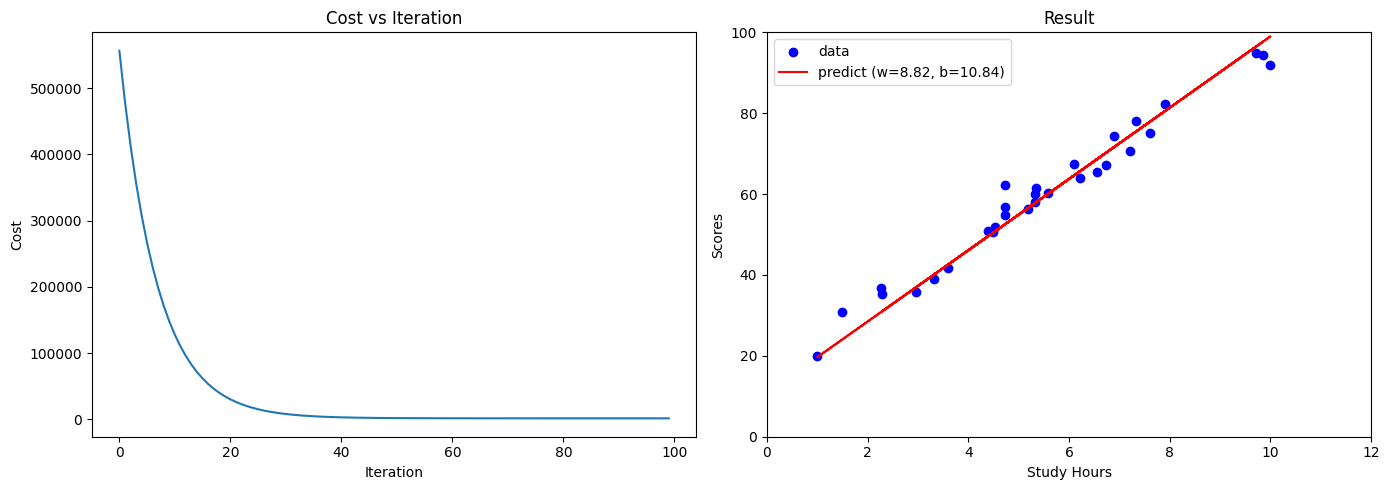

In [ ]:
def plot_convergence(hist, w_final, b_final):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 左圖：收斂曲線
    axes[0].plot(hist["cost"][:100])
    axes[0].set_title("Cost vs Iteration")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Cost")

    # 右圖：最終預測線
    axes[1].scatter(x, y, color="blue", label="data")
    axes[1].plot(x, w_final * x + b_final, color="red", label=f"predict (w={w_final:.2f}, b={b_final:.2f})")
    axes[1].set_xlabel("Study Hours")
    axes[1].set_ylabel("Scores")
    axes[1].set_xlim([0, 12])
    axes[1].set_ylim([0, 100])
    axes[1].legend()
    axes[1].set_title("Result")

    plt.tight_layout()
    plt.show()

plot_convergence(hist, w_final, b_final)

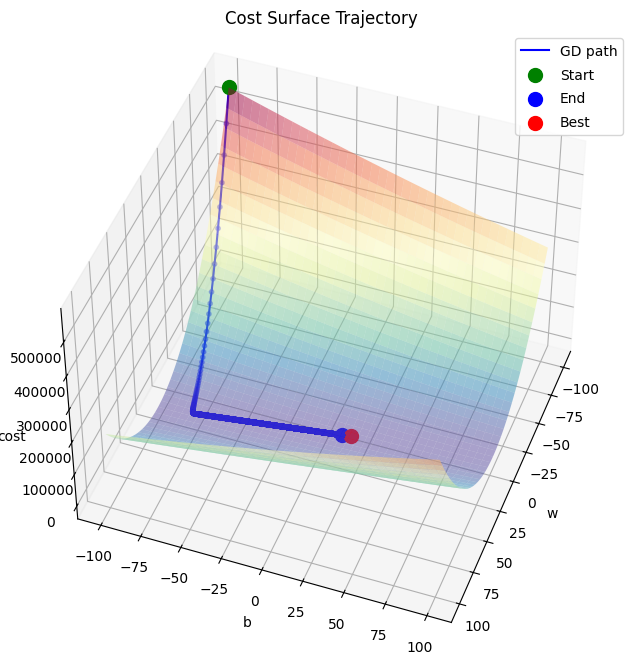

In [ ]:
def plot_3d_trajectory(hist, w_final, b_final, ax=None, elev=45, azim=20):
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection="3d")
    ax.view_init(elev, azim)

    b_grid, w_grid = np.meshgrid(bs, ws)
    ax.plot_surface(w_grid, b_grid, costs, cmap="Spectral_r", alpha=0.5)

    ax.plot(hist["w"], hist["b"], hist["cost"], color="blue", linewidth=1.5, label="GD path")
    ax.scatter(hist["w"], hist["b"], hist["cost"], color="blue", s=10, alpha=0.4)
    ax.scatter(hist["w"][0], hist["b"][0], hist["cost"][0], color="green", s=100, label="Start")
    ax.scatter(w_final, b_final, hist["cost"][-1], color="blue", s=100, label="End")
    ax.scatter(ws[w_idx], bs[b_idx], costs[w_idx, b_idx], color="red", s=100, label="Best")

    ax.set_xlabel("w")
    ax.set_ylabel("b")
    ax.set_zlabel("cost")
    ax.set_title("Cost Surface Trajectory")
    ax.legend(fontsize=10, labelspacing=0.7)

plot_3d_trajectory(hist, w_final, b_final)

## 10. Learning Rate 比較

學習率 $\alpha$ 是梯度下降關鍵的超參數：
- **太小**：收斂極慢，可能跑很久還沒到最低點
- **太大**：在最低點附近來回震盪甚至發散

Iter     0 | cost: 480051.5249 | w: -91.2077 | b: -98.5917
Iter     0 | cost: 479702.3877 | w: 137.3931 | b: -61.9746


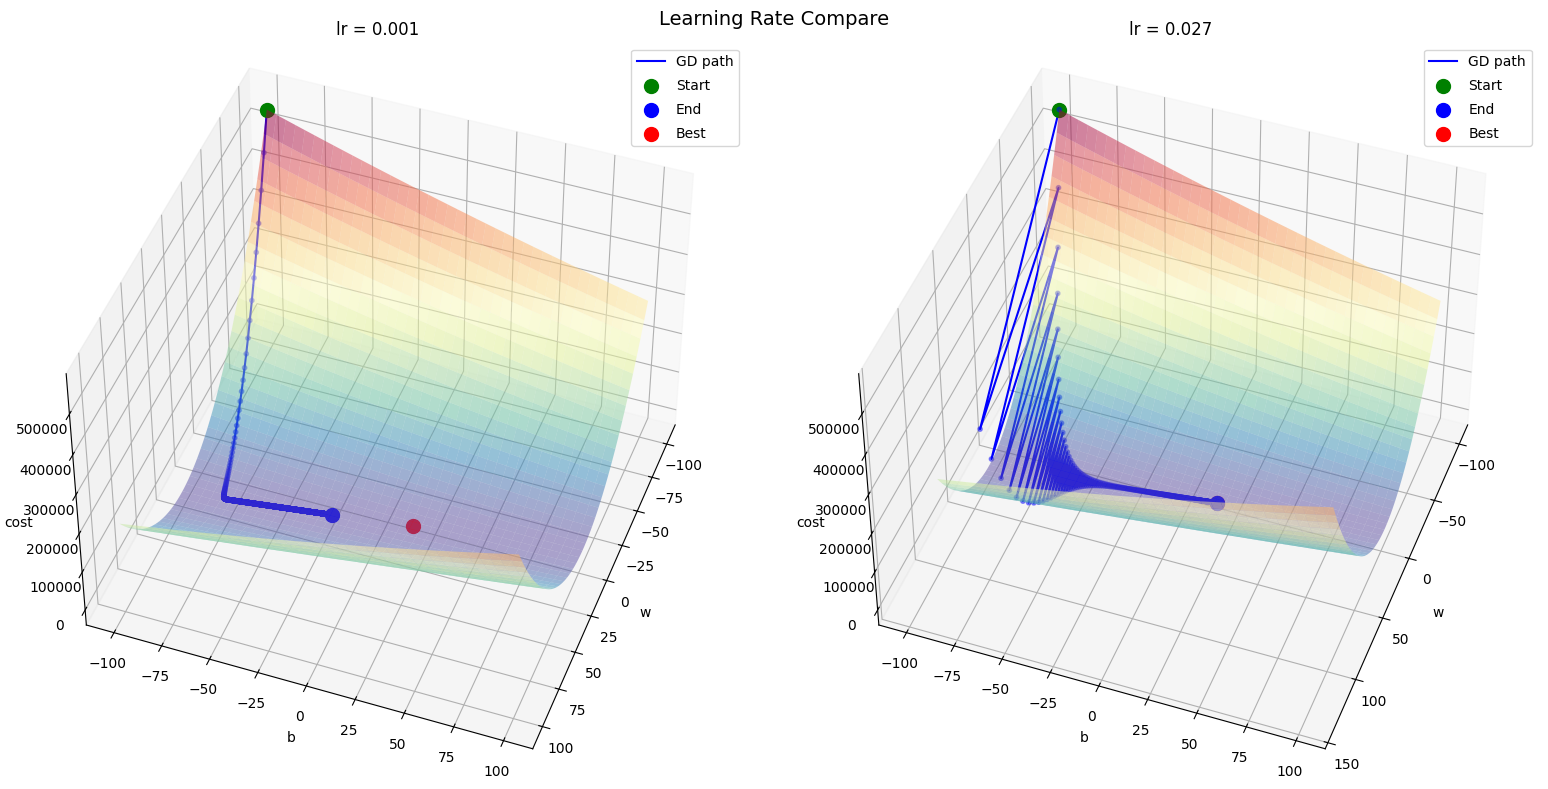

In [ ]:
lr_small, lr_large = 0.001, 0.027

fig = plt.figure(figsize=(16, 8))

for idx, lr in enumerate([lr_small, lr_large]):
    w, b, h = gradient_descent(x, y, -100, -100, lr, 3000, p_iter=99999)
    ax = fig.add_subplot(1, 2, idx + 1, projection="3d")
    plot_3d_trajectory(h, w, b, ax=ax)
    ax.set_title(f"lr = {lr}")

plt.suptitle("Learning Rate Compare", fontsize=14)
plt.tight_layout()
plt.show()

## 11. 用 scikit-learn 驗證

最後用 sklearn 的  LinearRegression 跑同樣的資料，看看兩者的 w, b, loss 是否接近

                              w            b         cost
---------------------------------------------------------
Gradient Descent         8.8157      10.8421    12.618946
sklearn                  7.9909      16.0995     8.495010
---------------------------------------------------------
diff                   0.824857     5.257399     4.123936



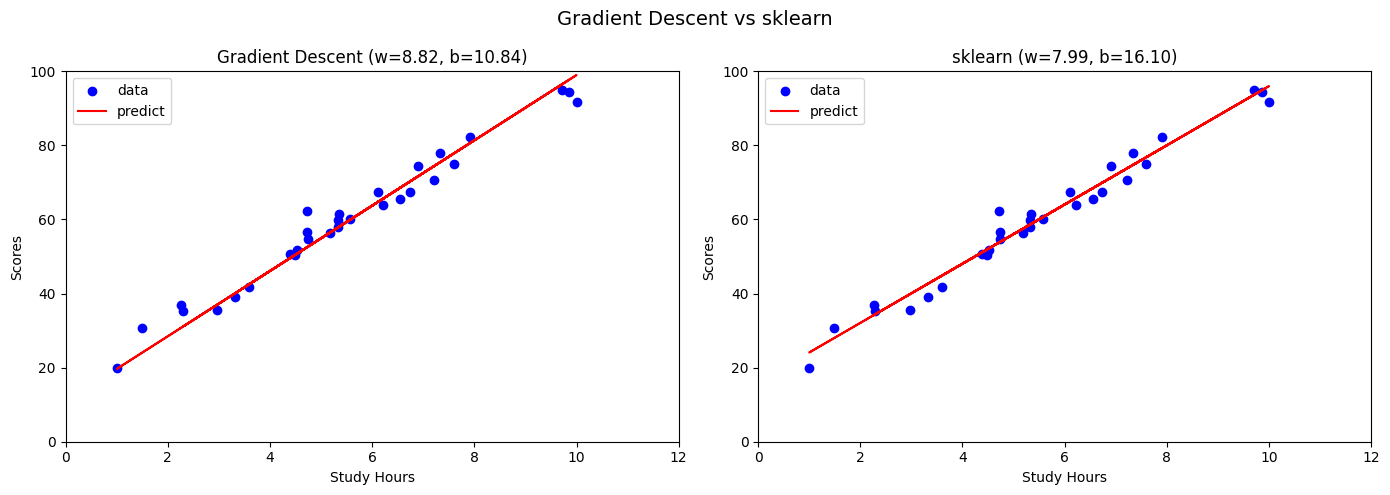

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

cost_gd = compute_cost(x, y, w_final, b_final)
cost_sk = compute_cost(x, y, model.coef_[0], model.intercept_)

print(f"{'':18s} {'w':>12s} {'b':>12s} {'cost':>12s}")
print(f"{'-'*57}")
print(f"{'Gradient Descent':18s} {w_final:>12.4f} {b_final:>12.4f} {cost_gd:>12.6f}")
print(f"{'sklearn':18s} {model.coef_[0]:>12.4f} {model.intercept_:>12.4f} {cost_sk:>12.6f}")
print(f"{'-'*57}")
print(f"{'diff':18s} {abs(w_final - model.coef_[0]):>12.6f} {abs(b_final - model.intercept_):>12.6f} {abs(cost_gd - cost_sk):>12.6f}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (w, b, title) in zip(axes, [
    (w_final, b_final, f"Gradient Descent (w={w_final:.2f}, b={b_final:.2f})"),
    (model.coef_[0], model.intercept_, f"sklearn (w={model.coef_[0]:.2f}, b={model.intercept_:.2f})")
]):
    ax.scatter(x, y, color="blue", label="data")
    ax.plot(x, w * x + b, color="red", label="predict")
    ax.set_xlabel("Study Hours")
    ax.set_ylabel("Scores")
    ax.set_xlim([0, 12])
    ax.set_ylim([0, 100])
    ax.set_title(title)
    ax.legend()

plt.suptitle("Gradient Descent vs sklearn", fontsize=14)
plt.tight_layout()
plt.show()